# DeepMTL2R Baseline Runner (Kaggle)

Notebook ini menjalankan eksperimen baseline (Single-Task vs Multi-Task Vanilla) menggunakan fungsi dari `run_baseline.py`, **tanpa bergantung pada debug config YAML**.

**Konfigurasi Fixed:**
- `TASK_INDICES_MT = [0, 131, 132, 133]` — 4 tasks (hardcoded, tidak dari input)
- `FOLDS = [1, 2]` — Fold yang dijalankan

Output utama:
- semua metrik per-fold dan agregasi mean±std
- `baseline_summary.json`
- plotting perbandingan metrik

In [1]:
!rm -rf /kaggle/working/DeepMTL2R
!git clone https://github.com/jteo0/DeepMTL2R.git

Cloning into 'DeepMTL2R'...
remote: Enumerating objects: 465, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 465 (delta 45), reused 66 (delta 33), pack-reused 371 (from 1)
Receiving objects: 100% (465/465), 17.83 MiB | 32.91 MiB/s, done.
Resolving deltas: 100% (211/211), done.


In [2]:
import os
import sys
import shutil
import subprocess
from contextlib import redirect_stdout, redirect_stderr

with open(os.devnull, 'w') as fnull:
    with redirect_stdout(fnull), redirect_stderr(fnull):

        # Install dependencies
        subprocess.run(
            ['pip', 'install', '-r', '/kaggle/working/DeepMTL2R/requirements.txt'],
            check=False
        )

        # Install editable package
        subprocess.run(
            ['pip', 'install', '-e', '/kaggle/working/DeepMTL2R'],
            check=False
        )

        # Copy dataset
        INPUT_DS = '/kaggle/input/mslr-web10k/MSLR-WEB10K'
        TARGET_DS = '/kaggle/working/DeepMTL2R/datasets/MSLR-WEB10K'

        if os.path.exists(INPUT_DS):
            os.makedirs(TARGET_DS, exist_ok=True)
            shutil.copytree(INPUT_DS, TARGET_DS, dirs_exist_ok=True)

        # Update PYTHONPATH
        if '/kaggle/working/DeepMTL2R' not in sys.path:
            sys.path.insert(0, '/kaggle/working/DeepMTL2R')

print("Setup complete.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 16.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.2.0
    Uninstalling fsspec-2026.2.0:
      Successfully uninstalled fsspec-2026.2.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2025.3.0 which is incompatible.


Obtaining file:///kaggle/working/DeepMTL2R
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py develop for dmtl2r
Setup complete.


In [3]:
# Jika perlu (Kaggle environment baru), jalankan install dependency:
# !pip install -r /kaggle/working/DeepMTL2R/requirements.txt

In [4]:
import gc
import json
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

Torch: 2.10.0+cu128
CUDA available: True


In [5]:
# ==============================
# Runtime Config (Notebook-owned)
# ==============================
# Ubah sesuai lokasi repo/dataset Anda di Kaggle.

PROJECT_ROOT = '/kaggle/working/DeepMTL2R'
EXAMPLE_DIR = os.path.join(PROJECT_ROOT, 'examples', 'MSLR-WEB10K')

DATASET_BASE_PATH = '/kaggle/input/datasets/engkhaledmo/mslr-10k/'

# ===== Debug config ditulis di Notebook (bukan dari YAML) =====
DEBUG_MODE = False
DEBUG_RATIO = 1e-6   # set 0.0 untuk full data
FOLDS = [1, 2]

# Task config (hardcoded untuk baseline)
TASK_INDICES_ST = [0]
TASK_INDICES_MT = [0, 131, 132, 133]
LABEL_INDICES = [131, 132, 133]
REDUCTION_METHOD = 'mean'

# Output
OUTPUT_DIR = os.path.join(EXAMPLE_DIR, 'outputs', 'results')
CHECKPOINT_DIR = os.path.join(EXAMPLE_DIR, 'checkpoints')

# Config JSON model baseline
CONFIG_GATING = os.path.join(EXAMPLE_DIR, 'configs', 'config_gating.json')

for p in [PROJECT_ROOT, EXAMPLE_DIR, OUTPUT_DIR, CHECKPOINT_DIR]:
    if not os.path.exists(p) and p in [OUTPUT_DIR, CHECKPOINT_DIR]:
        os.makedirs(p, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('EXAMPLE_DIR :', EXAMPLE_DIR)
print('DATASET_BASE_PATH:', DATASET_BASE_PATH)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('DEBUG_MODE:', DEBUG_MODE, '| DEBUG_RATIO:', DEBUG_RATIO)
print('TASK_INDICES_MT:', TASK_INDICES_MT, '(fixed)')

PROJECT_ROOT: /kaggle/working/DeepMTL2R
EXAMPLE_DIR : /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K
DATASET_BASE_PATH: /kaggle/input/datasets/engkhaledmo/mslr-10k/
OUTPUT_DIR: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results
DEBUG_MODE: False | DEBUG_RATIO: 1e-06
TASK_INDICES_MT: [0, 131, 132, 133] (fixed)


In [6]:
# Override training epochs for non-debug runs (Notebook-owned)
# This keeps the notebook independent from the JSON default of epochs=3.
EPOCHS_OVERRIDE = 50
ORIG_CONFIG_PATH = os.path.join(EXAMPLE_DIR, 'configs', 'config_gating.json')
OVERRIDE_CONFIG_PATH = os.path.join(EXAMPLE_DIR, 'configs', 'config_gating_epochs50.json')

with open(ORIG_CONFIG_PATH, 'r', encoding='utf-8') as f:
    _cfg = json.load(f)

_cfg.setdefault('training', {})
_cfg['training']['epochs'] = EPOCHS_OVERRIDE - 1  # Convert to 0-based: 50 - 1 = 49

with open(OVERRIDE_CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(_cfg, f, indent=2)

CONFIG_GATING = OVERRIDE_CONFIG_PATH
print('Config override written to:', CONFIG_GATING)
print('Epochs override: 1-50 (internally 0-49)')

Config override written to: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/configs/config_gating_epochs50.json
Epochs override: 1-50 (internally 0-49)


In [7]:
import sys
import importlib.util

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
if EXAMPLE_DIR not in sys.path:
    sys.path.insert(0, EXAMPLE_DIR)

RUN_BASELINE_PATH = os.path.join(EXAMPLE_DIR, 'run_baseline.py')
if os.path.exists(RUN_BASELINE_PATH):
    spec = importlib.util.spec_from_file_location('run_baseline', RUN_BASELINE_PATH)
    rb = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(rb)
else:
    import run_baseline as rb

# Override variabel global modul -> tidak bergantung debug config YAML
rb.DATASET_BASE_PATH = DATASET_BASE_PATH
rb.FOLDS = FOLDS
rb.REDUCTION_METHOD = REDUCTION_METHOD
rb.LABEL_INDICES = LABEL_INDICES
rb.OUTPUT_DIR = OUTPUT_DIR
rb.CHECKPOINT_DIR = CHECKPOINT_DIR
rb.CONFIG_GATING = CONFIG_GATING
rb.DEBUG = DEBUG_MODE

print('run_baseline loaded from:', RUN_BASELINE_PATH)
print('run_baseline globals overridden from notebook runtime config.')

run_baseline loaded from: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/run_baseline.py
run_baseline globals overridden from notebook runtime config.


/kaggle/working/DeepMTL2R/allrank/methods/min_norm_solvers.py:43: SyntaxWarning: invalid escape sequence '\s'
  ie. min_c |\sum c_i x_i|_2^2 st. \sum c_i = 1 , 1 >= c_1 >= 0 for all i, c_i + c_j = 1.0 for some i, j
/kaggle/working/DeepMTL2R/allrank/methods/min_norm_solvers.py:78: SyntaxWarning: invalid escape sequence '\s'
  Given y, it solves argmin_z |y-z|_2 st \sum z = 1 , 1 >= z_i >= 0 for all i
/kaggle/working/DeepMTL2R/allrank/methods/min_norm_solvers.py:113: SyntaxWarning: invalid escape sequence '\s'
  as min |u|_2 st. u = \sum c_i vecs[i] and \sum c_i = 1.
/kaggle/working/DeepMTL2R/allrank/methods/min_norm_solvers.py:160: SyntaxWarning: invalid escape sequence '\s'
  as min |u|_2 st. u = \sum c_i vecs[i] and \sum c_i = 1.


In [8]:
def summarize_metrics(agg_dict):
    out = {}
    for metric_name, values in agg_dict.items():
        arr = np.array(values, dtype=float)
        out[metric_name] = {
            'mean': float(np.mean(arr)),
            'std': float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0,
            'per_fold': [float(x) for x in arr.tolist()]
        }
    return out

def metrics_summary_to_df(summary_dict, experiment_name):
    rows = []
    for m, v in summary_dict.items():
        rows.append({
            'experiment': experiment_name,
            'metric': m,
            'mean': v['mean'],
            'std': v['std'],
        })
    return pd.DataFrame(rows).sort_values('metric').reset_index(drop=True)

In [9]:
# ==============================
# Run Baseline Experiments
# ==============================
all_ndcg30_st = []
all_ndcg30_mt = []
metrics_agg_st = defaultdict(list)
metrics_agg_mt = defaultdict(list)
params_st = []
params_mt = []
fold_details = []

for fold in FOLDS:
    print('\n' + '=' * 70)
    print(f'Processing Fold {fold}')
    print('=' * 70)

    dataset_path = os.path.join(DATASET_BASE_PATH, f'Fold{fold}')
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(f'Dataset path not found: {dataset_path}')

    config = rb.Config.from_json(CONFIG_GATING)

    max_rows = None
    if DEBUG_MODE and DEBUG_RATIO > 0:
        estimated_total_rows = 30000000
        max_rows = max(1, int(estimated_total_rows * DEBUG_RATIO))

    train_ds, val_ds = rb.load_libsvm_dataset(
        dataset_path, config.data.slate_length, config.data.validation_ds_role, max_rows=max_rows
    )

    nf = train_ds.shape[-1] - len(LABEL_INDICES)
    train_dl, val_dl = rb.create_data_loaders(
        train_ds, val_ds, config.data.num_workers, config.data.batch_size
    )

    # Single-task
    res_st = rb.run_training(
        experiment_name=f'Single-Task-Fold{fold}',
        task_indices=TASK_INDICES_ST,
        moo_method='ls',
        task_weights_tensor=torch.tensor([1.0]),
        dataset_path=dataset_path,
        train_dl=train_dl,
        val_dl=val_dl,
        nf=nf
    )

    task_metrics_st = dict(res_st.get('per_task_metrics', {}).get(0, {}))
    task_metrics_st.update({k: v for k, v in res_st.get('special_metrics', {}).items() if not isinstance(v, dict)})
    ndcg30_st = float(task_metrics_st.get('ndcg_30', 0.0))
    all_ndcg30_st.append(ndcg30_st)
    for k, v in task_metrics_st.items():
        if not isinstance(v, dict):
            metrics_agg_st[k].append(float(v))
    params_st.append(res_st.get('num_params'))

    # Multi-task vanilla
    num_tasks = len(TASK_INDICES_MT)
    res_mt = rb.run_training(
        experiment_name=f'Multi-Task-Vanilla-Fold{fold}',
        task_indices=TASK_INDICES_MT,
        moo_method='ls',
        task_weights_tensor=[1.0 / num_tasks] * num_tasks,
        dataset_path=dataset_path,
        train_dl=train_dl,
        val_dl=val_dl,
        nf=nf
    )

    task_metrics_mt = dict(res_mt.get('per_task_metrics', {}).get(0, {}))
    task_metrics_mt.update({k: v for k, v in res_mt.get('special_metrics', {}).items() if not isinstance(v, dict)})
    ndcg30_mt = float(task_metrics_mt.get('ndcg_30', 0.0))
    all_ndcg30_mt.append(ndcg30_mt)
    for k, v in task_metrics_mt.items():
        if not isinstance(v, dict):
            metrics_agg_mt[k].append(float(v))
    params_mt.append(res_mt.get('num_params'))

    fold_details.append({
        'fold': fold,
        'single_task_metrics': task_metrics_st,
        'multi_task_metrics': task_metrics_mt,
        'single_task_num_params': res_st.get('num_params'),
        'multi_task_num_params': res_mt.get('num_params')
    })

    del train_ds, val_ds, train_dl, val_dl
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

avg_ndcg30_st = float(np.mean(all_ndcg30_st)) if all_ndcg30_st else 0.0
avg_ndcg30_mt = float(np.mean(all_ndcg30_mt)) if all_ndcg30_mt else 0.0
delta_m = ((avg_ndcg30_mt - avg_ndcg30_st) / avg_ndcg30_st) * 100 if avg_ndcg30_st > 0 else 0.0

summary_st = summarize_metrics(metrics_agg_st)
summary_mt = summarize_metrics(metrics_agg_mt)

summary_out = {
    'folds': FOLDS,
    'debug_mode': DEBUG_MODE,
    'debug_ratio': DEBUG_RATIO,
    'delta_m_percent': float(delta_m),
    'single_task': {
        'ndcg30_avg': avg_ndcg30_st,
        'ndcg30_folds': [float(x) for x in all_ndcg30_st],
        'params_per_fold': params_st,
        'metrics': summary_st,
    },
    'multi_task': {
        'ndcg30_avg': avg_ndcg30_mt,
        'ndcg30_folds': [float(x) for x in all_ndcg30_mt],
        'params_per_fold': params_mt,
        'metrics': summary_mt,
    },
    'fold_details': fold_details
}

baseline_dir = os.path.join(OUTPUT_DIR, 'baselines')
os.makedirs(baseline_dir, exist_ok=True)
summary_path = os.path.join(baseline_dir, 'baseline_summary.json')
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary_out, f, indent=2, default=float)

print('\nBaseline summary saved to:', summary_path)
print(f'Single-Task NDCG@30 avg: {avg_ndcg30_st:.6f}')
print(f'Multi-Task  NDCG@30 avg: {avg_ndcg30_mt:.6f}')
print(f'Delta m%%: {delta_m:+.4f}%')
print('Single-Task metrics:')
for metric_name in sorted(summary_st.keys()):
    metric_stats = summary_st[metric_name]
    print(f"  {metric_name}: {metric_stats['mean']:.4f} ± {metric_stats['std']:.4f}")
print('Multi-Task metrics:')
for metric_name in sorted(summary_mt.keys()):
    metric_stats = summary_mt[metric_name]
    print(f"  {metric_name}: {metric_stats['mean']:.4f} ± {metric_stats['std']:.4f}")


Processing Fold 1

Starting run_training: Single-Task-Fold1, task_indices=[0]
Using device: cuda
will read config from /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/configs/config_gating_epochs50.json

--- Training Single-Task-Fold1 ---


Epoch 0/49 [Train]:   0%|          | 0/94 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/linear.py:134: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return F.linear(input, self.weight, self.bias)
Epoch 48/49 [Train]: 100%|██████████| 94/94 [00:06<00:00, 14.44it/s]



✓ Saved baseline model (deepmtl2r_fold1.pkl) to: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/checkpoints/deepmtl2r/deepmtl2r_fold1.pkl

Starting run_training: Multi-Task-Vanilla-Fold1, task_indices=[0, 131, 132, 133]
Using device: cuda
will read config from /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/configs/config_gating_epochs50.json

--- Training Multi-Task-Vanilla-Fold1 ---


Epoch 48/49 [Train]: 100%|██████████| 94/94 [00:27<00:00,  3.38it/s]



✓ Saved baseline model (deepmtl2r_fold1.pkl) to: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/checkpoints/deepmtl2r/deepmtl2r_fold1.pkl

Processing Fold 2

Starting run_training: Single-Task-Fold2, task_indices=[0]
Using device: cuda
will read config from /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/configs/config_gating_epochs50.json

--- Training Single-Task-Fold2 ---


Epoch 48/49 [Train]: 100%|██████████| 94/94 [00:06<00:00, 14.40it/s]



✓ Saved baseline model (deepmtl2r_fold2.pkl) to: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/checkpoints/deepmtl2r/deepmtl2r_fold2.pkl

Starting run_training: Multi-Task-Vanilla-Fold2, task_indices=[0, 131, 132, 133]
Using device: cuda
will read config from /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/configs/config_gating_epochs50.json

--- Training Multi-Task-Vanilla-Fold2 ---


Epoch 48/49 [Train]: 100%|██████████| 94/94 [00:27<00:00,  3.38it/s]



✓ Saved baseline model (deepmtl2r_fold2.pkl) to: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/checkpoints/deepmtl2r/deepmtl2r_fold2.pkl

Baseline summary saved to: /kaggle/working/DeepMTL2R/examples/MSLR-WEB10K/outputs/results/baselines/baseline_summary.json
Single-Task NDCG@30 avg: 0.511059
Multi-Task  NDCG@30 avg: 0.299771
Delta m%%: -41.3432%
Single-Task metrics:
  map_10: 0.5240 ± 0.0098
  mrr_10: 0.4092 ± 0.0077
  ndcg_1: 0.4208 ± 0.0085
  ndcg_10: 0.4423 ± 0.0044
  ndcg_20: 0.4801 ± 0.0033
  ndcg_30: 0.5111 ± 0.0030
  ndcg_5: 0.4206 ± 0.0005
Multi-Task metrics:
  map_10: 0.2965 ± 0.0075
  mrr_10: 0.1339 ± 0.0075
  ndcg_1: 0.1520 ± 0.0098
  ndcg_10: 0.2122 ± 0.0033
  ndcg_20: 0.2588 ± 0.0029
  ndcg_30: 0.2998 ± 0.0037
  ndcg_5: 0.1822 ± 0.0028


In [10]:
# Tampilkan semua metrik agregat (mean ± std)
df_st = metrics_summary_to_df(summary_st, 'single_task')
df_mt = metrics_summary_to_df(summary_mt, 'multi_task')
df_all = pd.concat([df_st, df_mt], axis=0, ignore_index=True)

pivot_mean = df_all.pivot(index='metric', columns='experiment', values='mean').sort_index()
pivot_std = df_all.pivot(index='metric', columns='experiment', values='std').sort_index()

display(df_all.sort_values(['metric', 'experiment']).reset_index(drop=True))
print('\nMean table:')
display(pivot_mean)
print('\nStd table:')
display(pivot_std)

,experiment,metric,mean,std
0,multi_task,map_10,0.296465,0.007475
1,single_task,map_10,0.524032,0.009765
2,multi_task,mrr_10,0.133868,0.007512
3,single_task,mrr_10,0.409179,0.007743
4,multi_task,ndcg_1,0.151964,0.009802
5,single_task,ndcg_1,0.420843,0.008519
6,multi_task,ndcg_10,0.212180,0.003345
7,single_task,ndcg_10,0.442299,0.004437
8,multi_task,ndcg_20,0.258786,0.002920
9,single_task,ndcg_20,0.480084,0.003346



Mean table:


experiment,multi_task,single_task
metric,,
map_10,0.296465,0.524032
mrr_10,0.133868,0.409179
ndcg_1,0.151964,0.420843
ndcg_10,0.212180,0.442299
ndcg_20,0.258786,0.480084
ndcg_30,0.299771,0.511059
ndcg_5,0.182193,0.420646



Std table:


experiment,multi_task,single_task
metric,,
map_10,0.007475,0.009765
mrr_10,0.007512,0.007743
ndcg_1,0.009802,0.008519
ndcg_10,0.003345,0.004437
ndcg_20,0.002920,0.003346
ndcg_30,0.003685,0.003047
ndcg_5,0.002822,0.000491


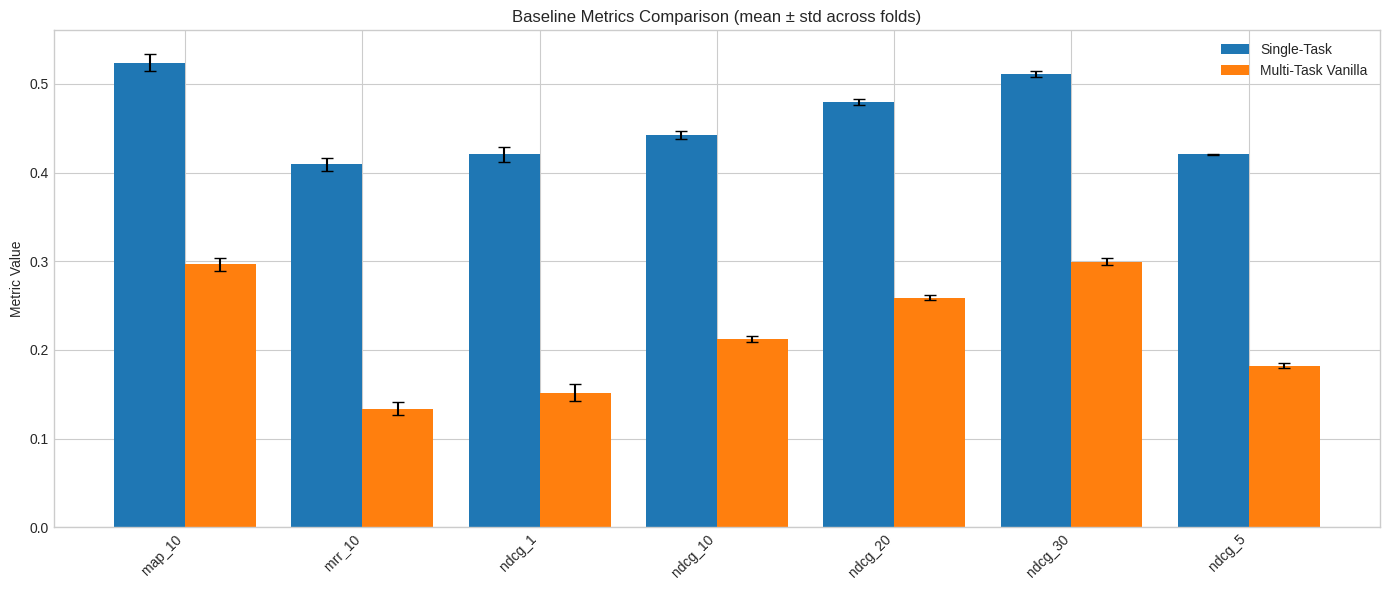

In [11]:
# Plot 1: Perbandingan mean ± std semua metrik
metrics = sorted(set(df_st['metric']).intersection(set(df_mt['metric'])))
x = np.arange(len(metrics))
width = 0.4

st_means = [summary_st[m]['mean'] for m in metrics]
st_stds = [summary_st[m]['std'] for m in metrics]
mt_means = [summary_mt[m]['mean'] for m in metrics]
mt_stds = [summary_mt[m]['std'] for m in metrics]

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, st_means, width, yerr=st_stds, capsize=4, label='Single-Task')
plt.bar(x + width/2, mt_means, width, yerr=mt_stds, capsize=4, label='Multi-Task Vanilla')
plt.xticks(x, metrics, rotation=45, ha='right')
plt.ylabel('Metric Value')
plt.title('Baseline Metrics Comparison (mean ± std across folds)')
plt.legend()
plt.tight_layout()
plt.show()

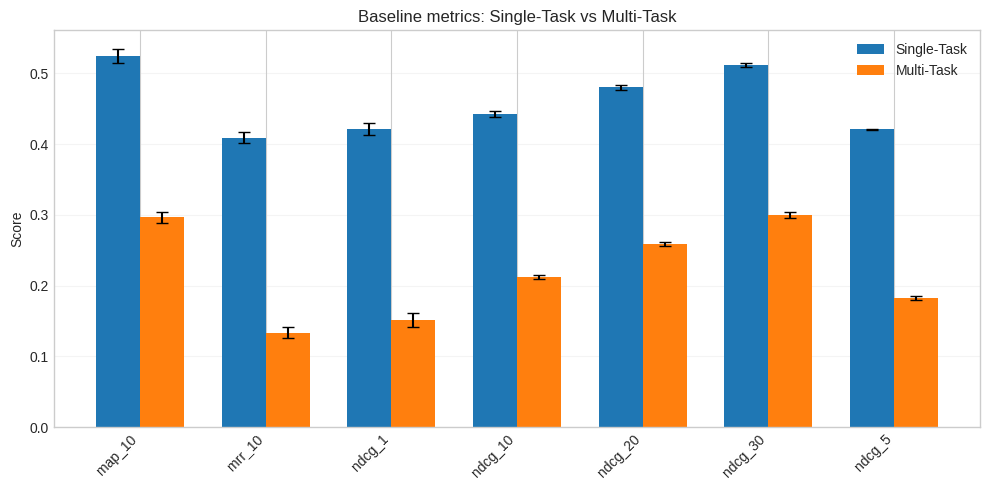

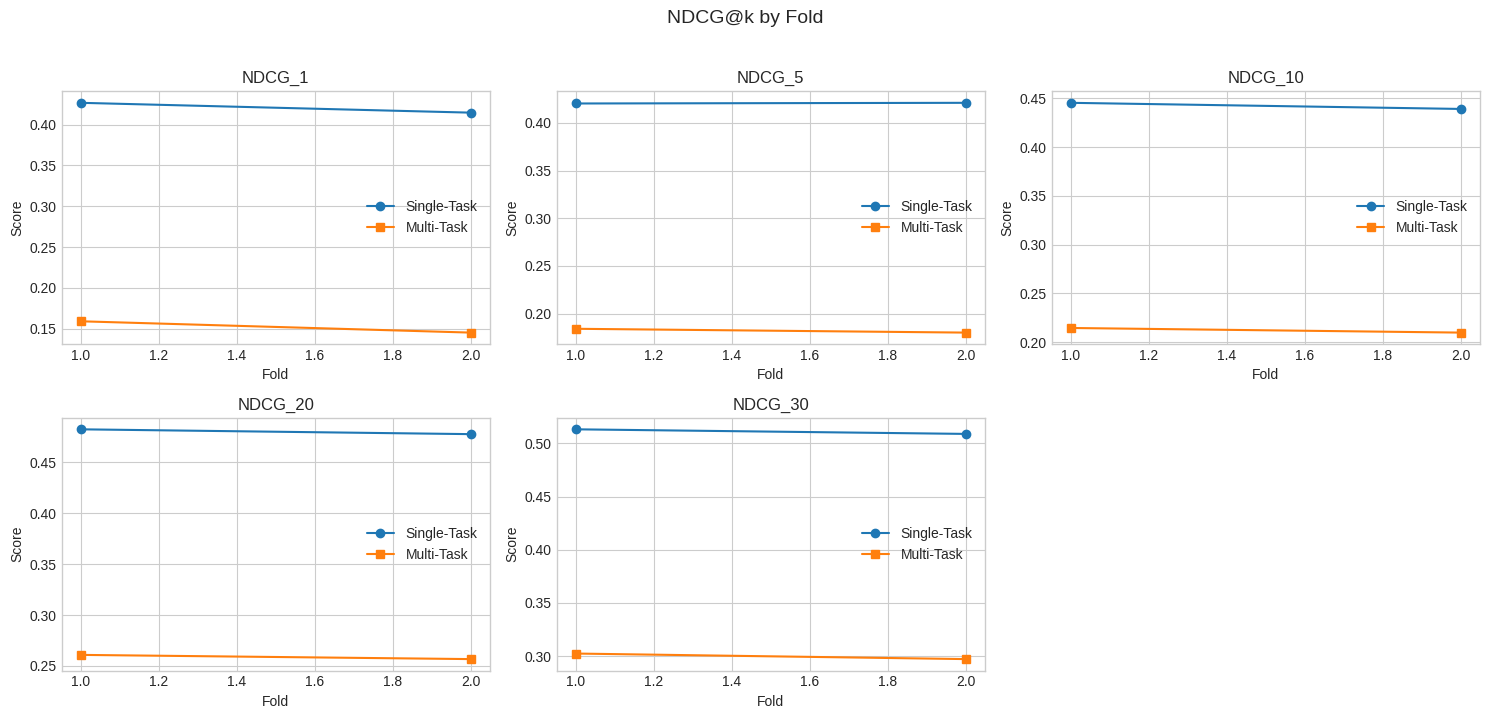

In [12]:
# Plot 2a: Perbandingan mean ± std semua metrik
metrics = sorted(set(df_st['metric']).intersection(set(df_mt['metric'])))
fig, ax = plt.subplots(figsize=(max(10, len(metrics) * 1.4), 5))
x = np.arange(len(metrics))
width = 0.35

st_means = [summary_st[m]['mean'] for m in metrics]
st_stds = [summary_st[m]['std'] for m in metrics]
mt_means = [summary_mt[m]['mean'] for m in metrics]
mt_stds = [summary_mt[m]['std'] for m in metrics]

ax.bar(x - width / 2, st_means, width, yerr=st_stds, capsize=4, label='Single-Task')
ax.bar(x + width / 2, mt_means, width, yerr=mt_stds, capsize=4, label='Multi-Task')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Baseline metrics: Single-Task vs Multi-Task')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# Plot 2b: Tren per fold untuk metrik NDCG@k
ndcg_metrics = sorted([m for m in metrics if m.startswith('ndcg_')], key=lambda x: int(x.split('_')[1]))

if ndcg_metrics:
    ncols = 3
    nrows = int(np.ceil(len(ndcg_metrics) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)

    for i, m in enumerate(ndcg_metrics):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        ax.plot(FOLDS, summary_st[m]['per_fold'], marker='o', label='Single-Task')
        ax.plot(FOLDS, summary_mt[m]['per_fold'], marker='s', label='Multi-Task')
        ax.set_title(m.upper())
        ax.set_xlabel('Fold')
        ax.set_ylabel('Score')
        ax.legend()

    # hide unused axes
    total_axes = nrows * ncols
    for j in range(len(ndcg_metrics), total_axes):
        r, c = divmod(j, ncols)
        axes[r][c].axis('off')

    fig.suptitle('NDCG@k by Fold', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No NDCG metrics found to plot.')

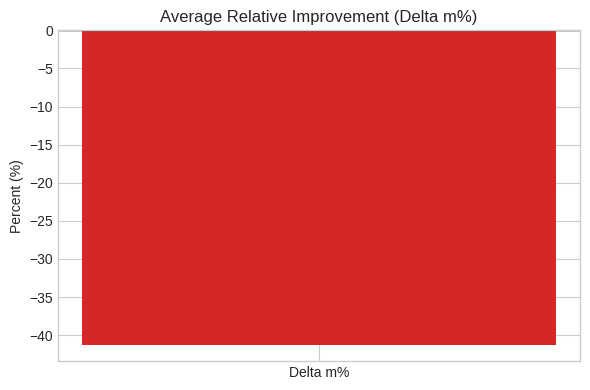

In [13]:
# Plot 3: Delta m% (NDCG@30)
plt.figure(figsize=(6, 4))
color = 'tab:green' if delta_m >= 0 else 'tab:red'
plt.bar(['Delta m%'], [delta_m], color=color)
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Percent (%)')
plt.title('Average Relative Improvement (Delta m%)')
plt.tight_layout()
plt.show()

In [14]:
# Zip checkpoint dan result agar mudah diunduh dari Kaggle
import os
import shutil

CHECKPOINTS_ROOT = os.path.join(CHECKPOINT_DIR, 'deepmtl2r')
RESULTS_ROOT = os.path.join(OUTPUT_DIR, 'baselines')
ZIP_DIR = os.path.join(PROJECT_ROOT, 'archives')
os.makedirs(ZIP_DIR, exist_ok=True)

checkpoint_zip_base = os.path.join(ZIP_DIR, 'deepmtl2r_checkpoints')
results_zip_base = os.path.join(ZIP_DIR, 'deepmtl2r_results')

if os.path.exists(CHECKPOINTS_ROOT):
    checkpoint_zip_path = shutil.make_archive(checkpoint_zip_base, 'zip', CHECKPOINTS_ROOT)
    print('Checkpoint ZIP:', checkpoint_zip_path)
else:
    print('Checkpoint folder not found:', CHECKPOINTS_ROOT)

if os.path.exists(RESULTS_ROOT):
    results_zip_path = shutil.make_archive(results_zip_base, 'zip', RESULTS_ROOT)
    print('Results ZIP:', results_zip_path)
else:
    print('Results folder not found:', RESULTS_ROOT)

print('Archive directory:', ZIP_DIR)

Checkpoint ZIP: /kaggle/working/DeepMTL2R/archives/deepmtl2r_checkpoints.zip
Results ZIP: /kaggle/working/DeepMTL2R/archives/deepmtl2r_results.zip
Archive directory: /kaggle/working/DeepMTL2R/archives


## Catatan
- Notebook ini khusus baseline (Single-Task vs Multi-Task Vanilla) dengan task indices hardcoded: `[0, 131, 132, 133]`
- Metrik khusus arsitektur tetap dipisahkan sesuai desain:
  - Effective Dimensionality Efficiency: hanya Matryoshka
  - Gating Sparsity Ratio: hanya Feature Gating
- Untuk mengubah task indices atau fold, edit variabel di cell konfigurasi (cell 6)
- Jika Anda ingin, notebook ini bisa diperluas untuk menjalankan ketiga eksperimen (Baseline, Matryoshka, Gating) dalam satu pipeline plotting gabungan.